In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from datetime import datetime
import os

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

if not os.path.exists('datos finales'):
    os.makedirs('datos finales')

print("\u2713 Importaciones completadas")

✓ Importaciones completadas


In [2]:
class MetodosNumericos:
    """Euler explícito, Heun (RK2) y Runge-Kutta 4.
    Funciona para EDOs escalares y para sistemas."""

    def __init__(self, f, t0, tf, y0, h):
        self.f = f
        self.t0 = t0
        self.tf = tf
        self.y0 = np.atleast_1d(np.asarray(y0, dtype=float))
        self.h = h
        self.t = np.arange(t0, tf + h, h)
        self.n = len(self.t)
        self.is_system = self.y0.size > 1
        self.evals_f = 0

    def _inicializar(self):
        if self.is_system:
            y = np.zeros((self.n, self.y0.size))
            y[0] = self.y0
        else:
            y = np.zeros(self.n)
            y[0] = self.y0[0]   # evita el DeprecationWarning array->escalar
        self.evals_f = 0
        return y

    def euler_explicito(self):
        """Euler: y_{n+1} = y_n + h*f(t_n, y_n)"""
        y = self._inicializar()
        for i in range(self.n - 1):
            y[i + 1] = y[i] + self.h * self.f(self.t[i], y[i])
            self.evals_f += 1
        return self.t, y

    def heun_rk2(self):
        """Heun (RK2), predictor-corrector"""
        y = self._inicializar()
        for i in range(self.n - 1):
            k1 = self.f(self.t[i], y[i])
            y_pred = y[i] + self.h * k1
            k2 = self.f(self.t[i + 1], y_pred)
            y[i + 1] = y[i] + (self.h / 2) * (k1 + k2)
            self.evals_f += 2
        return self.t, y

    def rk4(self):
        """Runge-Kutta de orden 4 clásico"""
        y = self._inicializar()
        for i in range(self.n - 1):
            k1 = self.f(self.t[i], y[i])
            k2 = self.f(self.t[i] + self.h/2, y[i] + (self.h/2)*k1)
            k3 = self.f(self.t[i] + self.h/2, y[i] + (self.h/2)*k2)
            k4 = self.f(self.t[i] + self.h,   y[i] + self.h*k3)
            y[i + 1] = y[i] + (self.h/6) * (k1 + 2*k2 + 2*k3 + k4)
            self.evals_f += 4
        return self.t, y

    def calcular_error(self, y_numerica, y_exacta):
        return np.max(np.abs(y_numerica - y_exacta))

print("\u2713 Clase MetodosNumericos definida")

✓ Clase MetodosNumericos definida


In [3]:
class EcuacionesPrueba:
    """Ecuaciones del anteproyecto con sus soluciones analíticas."""

    # ===== PRIMER ORDEN =====
    @staticmethod
    def edo1_1(t, y):
        """y' = -2y + e^(-t),  y(0) = 0"""
        return -2*y + np.exp(-t)

    @staticmethod
    def sol_exacta_edo1_1(t):
        """y(t) = e^(-t) - e^(-2t)"""
        return np.exp(-t) - np.exp(-2*t)

    @staticmethod
    def edo1_2(t, y):
        """y' = y*cos(t),  y(0) = 1"""
        return y * np.cos(t)

    @staticmethod
    def sol_exacta_edo1_2(t):
        """y(t) = e^(sin(t))"""
        return np.exp(np.sin(t))

    # ===== SEGUNDO ORDEN (como sistema) =====
    @staticmethod
    def edo2_1(t, y):
        """y'' + 4y = 0,  y(0)=1, y'(0)=0"""
        y1, y2 = y
        return np.array([y2, -4*y1])

    @staticmethod
    def sol_exacta_edo2_1(t):
        """y(t) = cos(2t)"""
        return np.cos(2*t)

    # ===== SISTEMAS LINEALES 2x2 =====
    @staticmethod
    def sistema1_lineal(t, y):
        """x' = 3x - 5y,  y' = 8x - 12y,  x(0)=1, y(0)=0"""
        x, y_var = y
        return np.array([3*x - 5*y_var, 8*x - 12*y_var])

    @staticmethod
    def sol_exacta_sistema1_lineal(t):
        """Autovalores lambda = (-9 +- sqrt(65))/2;  x(0)=1, y(0)=0"""
        s = np.sqrt(65)
        l1 = (-9 + s) / 2
        l2 = (-9 - s) / 2
        C1 = (15 + s) / (2 * s)
        C2 = (s - 15) / (2 * s)
        a1 = (15 - s) / 10
        a2 = (15 + s) / 10
        x = C1*np.exp(l1*t) + C2*np.exp(l2*t)
        y = C1*a1*np.exp(l1*t) + C2*a2*np.exp(l2*t)
        return np.array([x, y])

    @staticmethod
    def sistema2_lineal(t, y):
        """dx/dt = -x + y,  dy/dt = -2y  (autovalores -1, -2)"""
        x, y_var = y
        return np.array([-x + y_var, -2*y_var])

    @staticmethod
    def sol_exacta_sistema2_lineal(t):
        """x(t) = 2e^(-t) - e^(-2t),  y(t) = e^(-2t);  x(0)=1, y(0)=1"""
        return np.array([2*np.exp(-t) - np.exp(-2*t), np.exp(-2*t)])

    # ===== SISTEMAS NO LINEALES (Lotka-Volterra) =====
    @staticmethod
    def lotka_volterra1(t, y):
        """dx/dt = x - xy,  dy/dt = xy - y,  x(0)=2, y(0)=1"""
        x, y_var = y
        return np.array([x - x*y_var, x*y_var - y_var])

    @staticmethod
    def lotka_volterra2(t, y):
        """dx/dt = 1.1x - 0.4xy,  dy/dt = 0.1xy - 0.4y,  x(0)=10, y(0)=5"""
        x, y_var = y
        return np.array([1.1*x - 0.4*x*y_var, 0.1*x*y_var - 0.4*y_var])

print("\u2713 Ecuaciones de prueba definidas")

✓ Ecuaciones de prueba definidas


In [4]:
def calcular_orden_convergencia(h_vals, error_vals):
    """Ajusta log(error) = p*log(h) + b ; retorna pendiente p (orden) y R²."""
    log_h = np.log10(h_vals)
    log_err = np.log10(error_vals)
    coeffs = np.polyfit(log_h, log_err, 1)
    pendiente = coeffs[0]
    y_pred = np.polyval(coeffs, log_h)
    ss_res = np.sum((log_err - y_pred)**2)
    ss_tot = np.sum((log_err - np.mean(log_err))**2)
    r_squared = 1 - (ss_res / ss_tot)
    return pendiente, r_squared

# Diccionario global para el resumen final
resumen_ordenes = {}
pasos_h = np.array([0.40, 0.20, 0.10, 0.05])

print("\u2713 Función de convergencia definida")

✓ Función de convergencia definida


In [5]:
print("="*70)
print("PRUEBA 1: y' = -2y + e^(-t), y(0) = 0")
print("Solución analítica: y(t) = e^(-t) - e^(-2t)")
print("="*70)

resultados_p1 = []
for h in pasos_h:
    s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h)
    t_e, y_e = s.euler_explicito(); ev_e = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h)
    t_h, y_h = s.heun_rk2();        ev_h = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h)
    t_r, y_r = s.rk4();             ev_r = s.evals_f

    err_e = np.max(np.abs(y_e - EcuacionesPrueba.sol_exacta_edo1_1(t_e)))
    err_h = np.max(np.abs(y_h - EcuacionesPrueba.sol_exacta_edo1_1(t_h)))
    err_r = np.max(np.abs(y_r - EcuacionesPrueba.sol_exacta_edo1_1(t_r)))

    resultados_p1.append({'h': h, 'Euler': err_e, 'Heun': err_h, 'RK4': err_r,
        'Evals_Euler': ev_e, 'Evals_Heun': ev_h, 'Evals_RK4': ev_r})

df_p1 = pd.DataFrame(resultados_p1)
print("\nErrores globales máximos:")
print(df_p1[['h','Euler','Heun','RK4']].to_string(index=False))
df_p1.to_csv('datos finales/prueba1_edo_primer_orden.csv', index=False)
print("\n\u2713 Resultados exportados a CSV")

PRUEBA 1: y' = -2y + e^(-t), y(0) = 0
Solución analítica: y(t) = e^(-t) - e^(-2t)

Errores globales máximos:
   h    Euler     Heun          RK4
0.40 0.179009 0.046927 1.706569e-03
0.20 0.062755 0.008362 7.369581e-05
0.10 0.027699 0.001753 3.831311e-06
0.05 0.013145 0.000402 2.194098e-07

✓ Resultados exportados a CSV


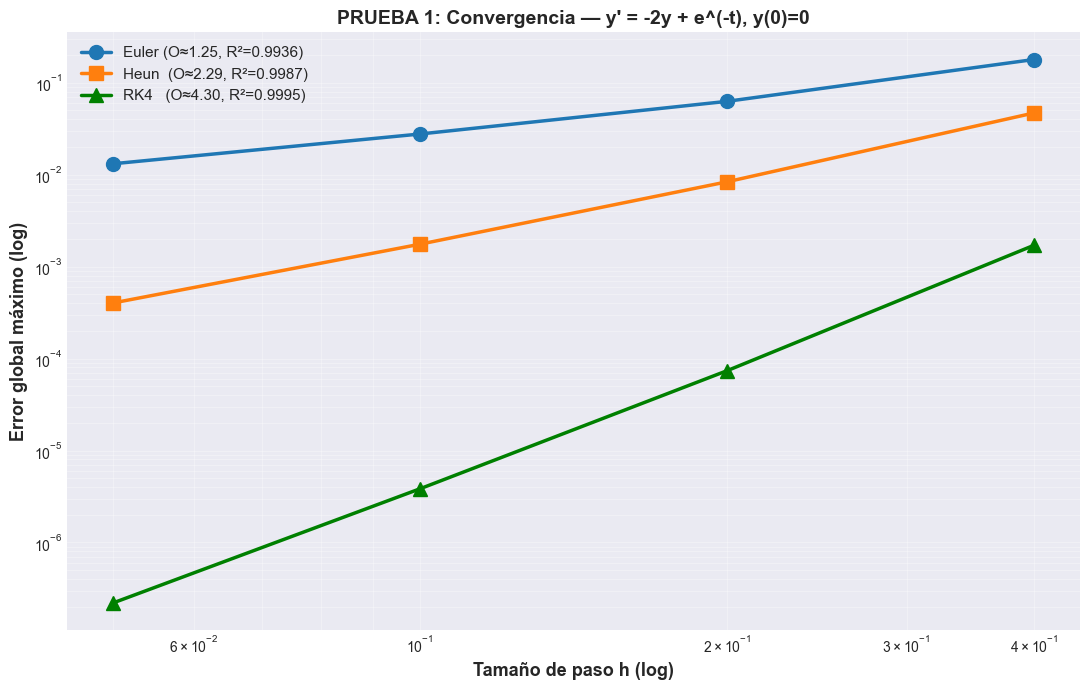


Órdenes observados:  Euler=1.248  Heun=2.285  RK4=4.304


In [6]:
fig, ax = plt.subplots(figsize=(11, 7))
e_e = df_p1['Euler'].values; e_h = df_p1['Heun'].values; e_r = df_p1['RK4'].values
o_e, r_e = calcular_orden_convergencia(pasos_h, e_e)
o_h, r_h = calcular_orden_convergencia(pasos_h, e_h)
o_r, r_r = calcular_orden_convergencia(pasos_h, e_r)
resumen_ordenes["P1"] = (o_e, o_h, o_r)

ax.loglog(pasos_h, e_e, 'o-', label=f'Euler (O\u2248{o_e:.2f}, R\u00b2={r_e:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h, e_h, 's-', label=f'Heun  (O\u2248{o_h:.2f}, R\u00b2={r_h:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h, e_r, '^-', label=f'RK4   (O\u2248{o_r:.2f}, R\u00b2={r_r:.4f})', linewidth=2.5, markersize=10, color='green')
ax.set_xlabel('Tamaño de paso h (log)', fontsize=13, fontweight='bold')
ax.set_ylabel('Error global máximo (log)', fontsize=13, fontweight='bold')
ax.set_title("PRUEBA 1: Convergencia — y' = -2y + e^(-t), y(0)=0", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p1_convergencia.png', dpi=300); plt.show()

print(f"\nÓrdenes observados:  Euler={o_e:.3f}  Heun={o_h:.3f}  RK4={o_r:.3f}")

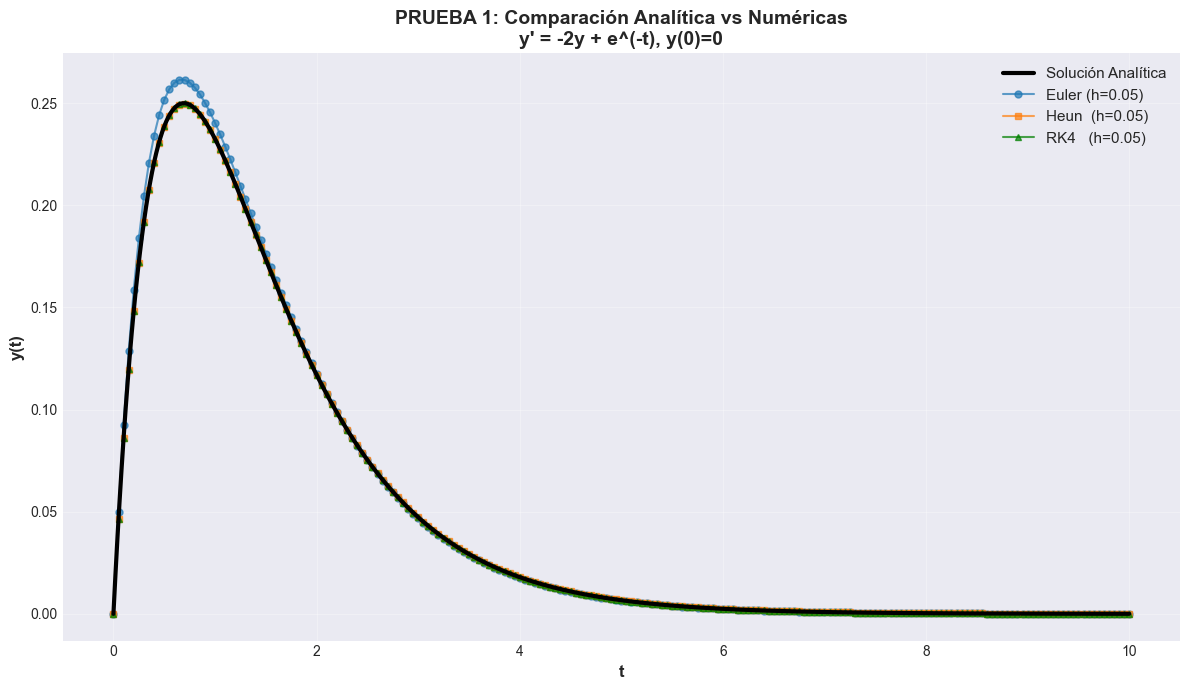

In [7]:
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h_comp); t_r, y_r = s.rk4()
t_ex = np.linspace(0, 10, 500); y_ex = EcuacionesPrueba.sol_exacta_edo1_1(t_ex)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(t_ex, y_ex, 'k-', linewidth=3, label='Solución Analítica', zorder=5)
ax.plot(t_e, y_e, 'o-', label=f'Euler (h={h_comp})', alpha=0.7, markersize=5)
ax.plot(t_h, y_h, 's-', label=f'Heun  (h={h_comp})', alpha=0.7, markersize=5)
ax.plot(t_r, y_r, '^-', label=f'RK4   (h={h_comp})', alpha=0.7, markersize=5, color='green')
ax.set_xlabel('t', fontsize=12, fontweight='bold'); ax.set_ylabel('y(t)', fontsize=12, fontweight='bold')
ax.set_title("PRUEBA 1: Comparación Analítica vs Numéricas\ny' = -2y + e^(-t), y(0)=0", fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p1_comparacion.png', dpi=300); plt.show()

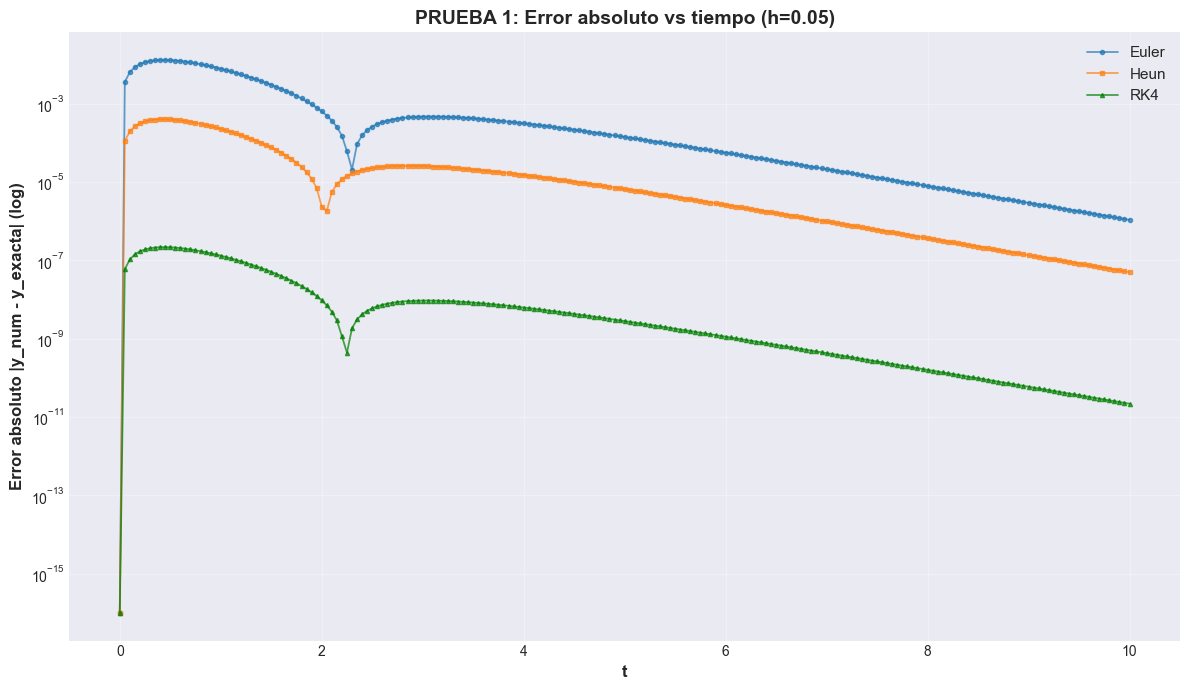

In [8]:
# Error absoluto vs tiempo (semilog) - P1
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.edo1_1, 0, 10, 0.0, h_comp); t_r, y_r = s.rk4()

err_e = np.maximum(np.abs(y_e - EcuacionesPrueba.sol_exacta_edo1_1(t_e)), 1e-16)
err_h = np.maximum(np.abs(y_h - EcuacionesPrueba.sol_exacta_edo1_1(t_h)), 1e-16)
err_r = np.maximum(np.abs(y_r - EcuacionesPrueba.sol_exacta_edo1_1(t_r)), 1e-16)

fig, ax = plt.subplots(figsize=(12, 7))
ax.semilogy(t_e, err_e, 'o-', label='Euler', alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_h, err_h, 's-', label='Heun',  alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_r, err_r, '^-', label='RK4',   alpha=0.7, linewidth=1.3, markersize=3, color='green')
ax.set_xlabel('t', fontsize=12, fontweight='bold')
ax.set_ylabel('Error absoluto |y_num - y_exacta| (log)', fontsize=12, fontweight='bold')
ax.set_title("PRUEBA 1: Error absoluto vs tiempo (h=0.05)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p1_error_tiempo.png', dpi=300); plt.show()

In [9]:
print("="*70)
print("PRUEBA 2: y' = y*cos(t), y(0) = 1")
print("Solución analítica: y(t) = e^(sin(t))")
print("="*70)

resultados_p2 = []
for h in pasos_h:
    s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h)
    t_e, y_e = s.euler_explicito(); ev_e = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h)
    t_h, y_h = s.heun_rk2();        ev_h = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h)
    t_r, y_r = s.rk4();             ev_r = s.evals_f

    err_e = np.max(np.abs(y_e - EcuacionesPrueba.sol_exacta_edo1_2(t_e)))
    err_h = np.max(np.abs(y_h - EcuacionesPrueba.sol_exacta_edo1_2(t_h)))
    err_r = np.max(np.abs(y_r - EcuacionesPrueba.sol_exacta_edo1_2(t_r)))

    resultados_p2.append({'h': h, 'Euler': err_e, 'Heun': err_h, 'RK4': err_r,
        'Evals_Euler': ev_e, 'Evals_Heun': ev_h, 'Evals_RK4': ev_r})

df_p2 = pd.DataFrame(resultados_p2)
print("\nErrores globales máximos:")
print(df_p2[['h','Euler','Heun','RK4']].to_string(index=False))
df_p2.to_csv('datos finales/prueba2_edo_primer_orden2.csv', index=False)
print("\n\u2713 Resultados exportados a CSV")

PRUEBA 2: y' = y*cos(t), y(0) = 1
Solución analítica: y(t) = e^(sin(t))

Errores globales máximos:
   h    Euler     Heun          RK4
0.40 1.310740 0.107037 4.649745e-04
0.20 0.731505 0.023689 2.343998e-05
0.10 0.389518 0.005611 1.291790e-06
0.05 0.201478 0.001362 7.529291e-08

✓ Resultados exportados a CSV


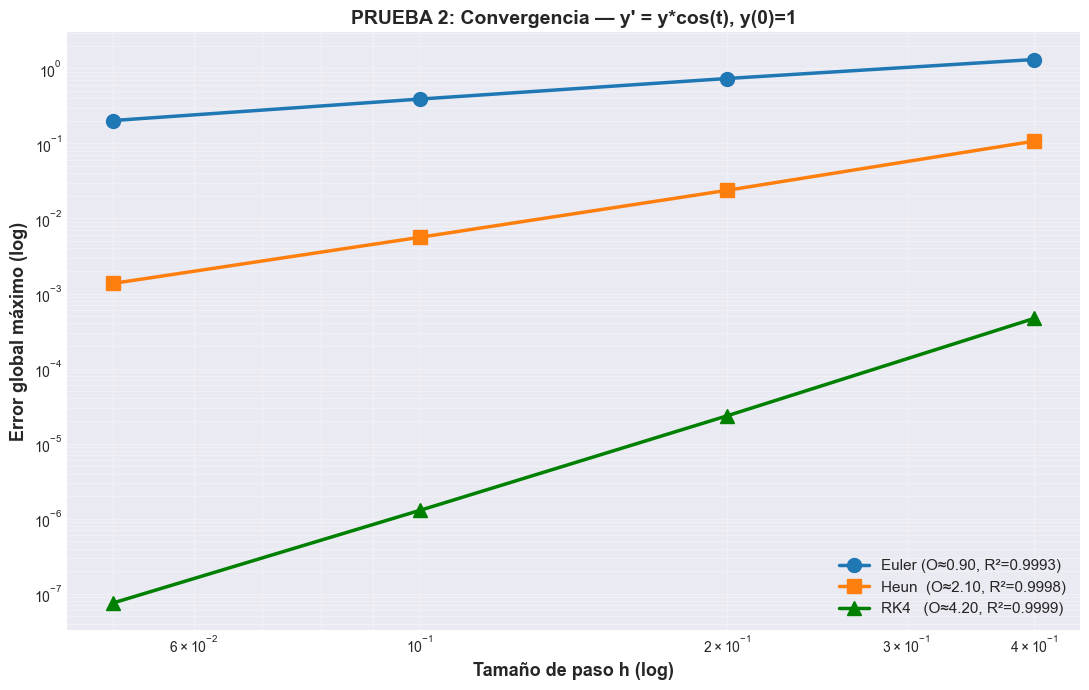


Órdenes observados:  Euler=0.901  Heun=2.097  RK4=4.196


In [10]:
fig, ax = plt.subplots(figsize=(11, 7))
e_e = df_p2['Euler'].values; e_h = df_p2['Heun'].values; e_r = df_p2['RK4'].values
o_e, r_e = calcular_orden_convergencia(pasos_h, e_e)
o_h, r_h = calcular_orden_convergencia(pasos_h, e_h)
o_r, r_r = calcular_orden_convergencia(pasos_h, e_r)
resumen_ordenes["P2"] = (o_e, o_h, o_r)

ax.loglog(pasos_h, e_e, 'o-', label=f'Euler (O\u2248{o_e:.2f}, R\u00b2={r_e:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h, e_h, 's-', label=f'Heun  (O\u2248{o_h:.2f}, R\u00b2={r_h:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h, e_r, '^-', label=f'RK4   (O\u2248{o_r:.2f}, R\u00b2={r_r:.4f})', linewidth=2.5, markersize=10, color='green')
ax.set_xlabel('Tamaño de paso h (log)', fontsize=13, fontweight='bold')
ax.set_ylabel('Error global máximo (log)', fontsize=13, fontweight='bold')
ax.set_title("PRUEBA 2: Convergencia — y' = y*cos(t), y(0)=1", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p2_convergencia.png', dpi=300); plt.show()

print(f"\nÓrdenes observados:  Euler={o_e:.3f}  Heun={o_h:.3f}  RK4={o_r:.3f}")

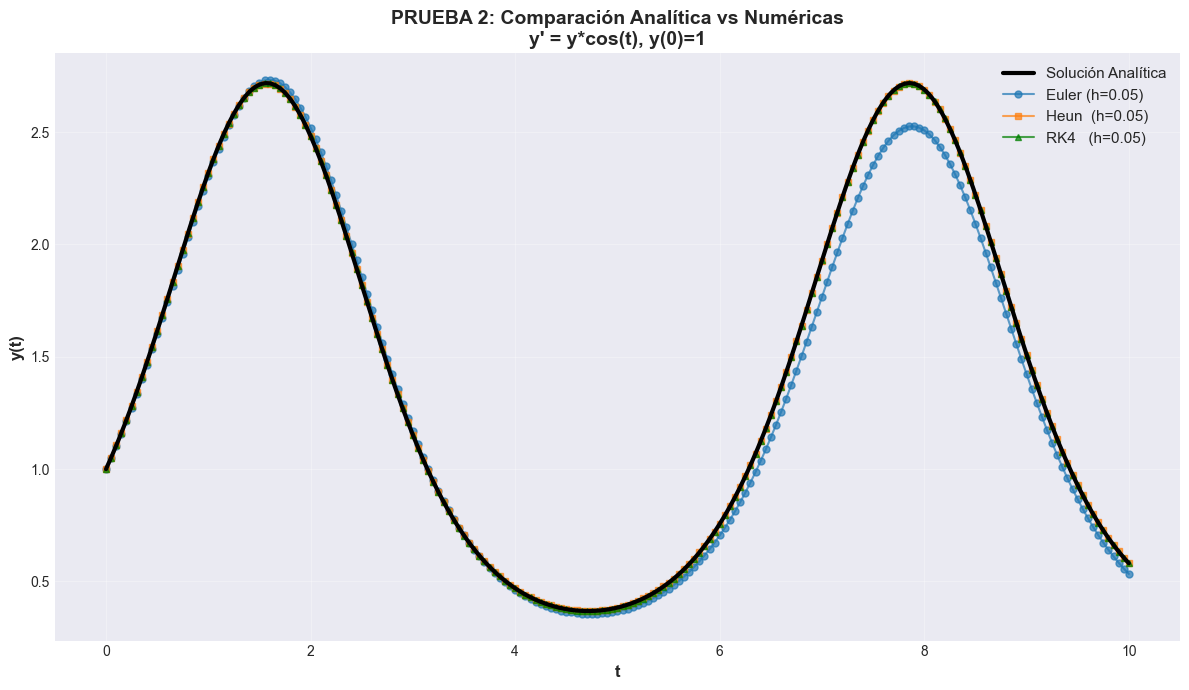

In [11]:
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h_comp); t_r, y_r = s.rk4()
t_ex = np.linspace(0, 10, 500); y_ex = EcuacionesPrueba.sol_exacta_edo1_2(t_ex)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(t_ex, y_ex, 'k-', linewidth=3, label='Solución Analítica', zorder=5)
ax.plot(t_e, y_e, 'o-', label=f'Euler (h={h_comp})', alpha=0.7, markersize=5)
ax.plot(t_h, y_h, 's-', label=f'Heun  (h={h_comp})', alpha=0.7, markersize=5)
ax.plot(t_r, y_r, '^-', label=f'RK4   (h={h_comp})', alpha=0.7, markersize=5, color='green')
ax.set_xlabel('t', fontsize=12, fontweight='bold'); ax.set_ylabel('y(t)', fontsize=12, fontweight='bold')
ax.set_title("PRUEBA 2: Comparación Analítica vs Numéricas\ny' = y*cos(t), y(0)=1", fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p2_comparacion.png', dpi=300); plt.show()

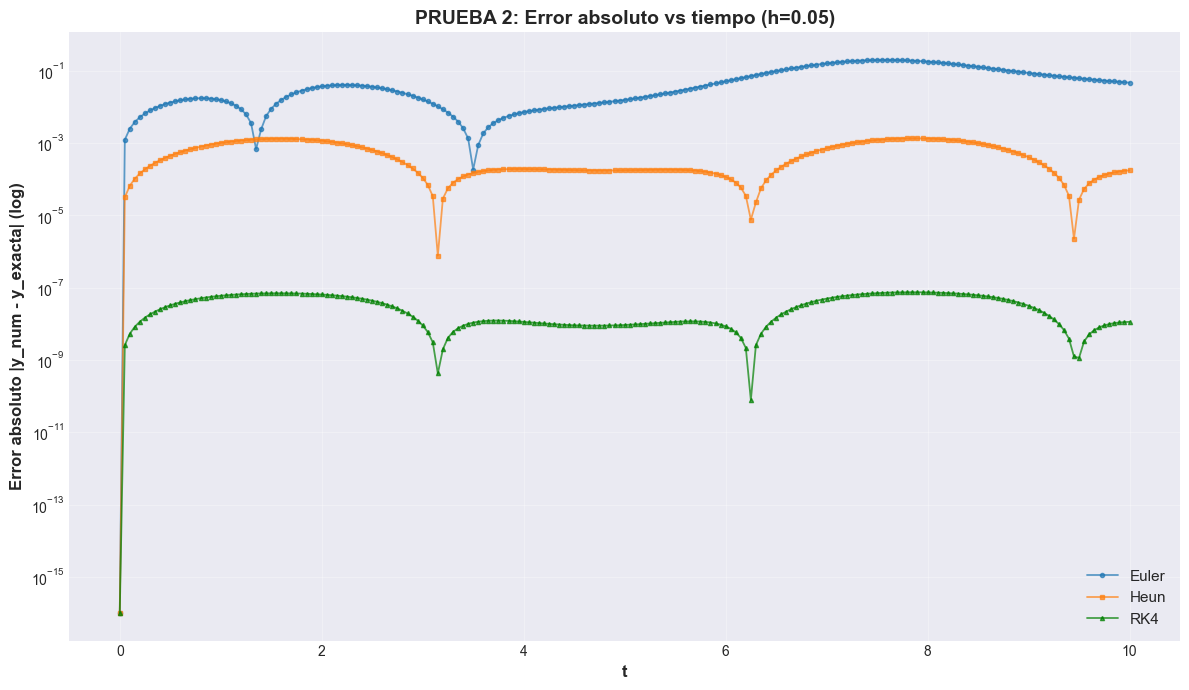

In [12]:
# Error absoluto vs tiempo (semilog) - P2
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.edo1_2, 0, 10, 1.0, h_comp); t_r, y_r = s.rk4()

err_e = np.maximum(np.abs(y_e - EcuacionesPrueba.sol_exacta_edo1_2(t_e)), 1e-16)
err_h = np.maximum(np.abs(y_h - EcuacionesPrueba.sol_exacta_edo1_2(t_h)), 1e-16)
err_r = np.maximum(np.abs(y_r - EcuacionesPrueba.sol_exacta_edo1_2(t_r)), 1e-16)

fig, ax = plt.subplots(figsize=(12, 7))
ax.semilogy(t_e, err_e, 'o-', label='Euler', alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_h, err_h, 's-', label='Heun',  alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_r, err_r, '^-', label='RK4',   alpha=0.7, linewidth=1.3, markersize=3, color='green')
ax.set_xlabel('t', fontsize=12, fontweight='bold')
ax.set_ylabel('Error absoluto |y_num - y_exacta| (log)', fontsize=12, fontweight='bold')
ax.set_title("PRUEBA 2: Error absoluto vs tiempo (h=0.05)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p2_error_tiempo.png', dpi=300); plt.show()

In [13]:
print("="*70)
print("PRUEBA 3: y'' + 4y = 0, y(0)=1, y'(0)=0")
print("Solución analítica: y(t) = cos(2t)")
print("Nota: Euler es inestable (autovalores +-2i imaginarios puros)")
print("="*70)

resultados_p3 = []
for h in pasos_h:
    s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h)
    t_e, y_e = s.euler_explicito(); ev_e = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h)
    t_h, y_h = s.heun_rk2();        ev_h = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h)
    t_r, y_r = s.rk4();             ev_r = s.evals_f

    err_e = np.max(np.abs(y_e[:, 0] - EcuacionesPrueba.sol_exacta_edo2_1(t_e)))
    err_h = np.max(np.abs(y_h[:, 0] - EcuacionesPrueba.sol_exacta_edo2_1(t_h)))
    err_r = np.max(np.abs(y_r[:, 0] - EcuacionesPrueba.sol_exacta_edo2_1(t_r)))

    resultados_p3.append({'h': h, 'Euler': err_e, 'Heun': err_h, 'RK4': err_r,
        'Evals_Euler': ev_e, 'Evals_Heun': ev_h, 'Evals_RK4': ev_r})

df_p3 = pd.DataFrame(resultados_p3)
print("\nErrores globales máximos:")
print(df_p3[['h','Euler','Heun','RK4']].to_string(index=False))
df_p3.to_csv('datos finales/prueba3_edo_segundo_orden.csv', index=False)
print("\n\u2713 Resultados exportados a CSV")

PRUEBA 3: y'' + 4y = 0, y(0)=1, y'(0)=0
Solución analítica: y(t) = cos(2t)
Nota: Euler es inestable (autovalores +-2i imaginarios puros)

Errores globales máximos:
   h      Euler     Heun      RK4
0.40 335.690465 3.604129 0.055663
0.20  39.836429 0.508846 0.003746
0.10   5.598208 0.117683 0.000232
0.05   1.574990 0.029615 0.000015

✓ Resultados exportados a CSV


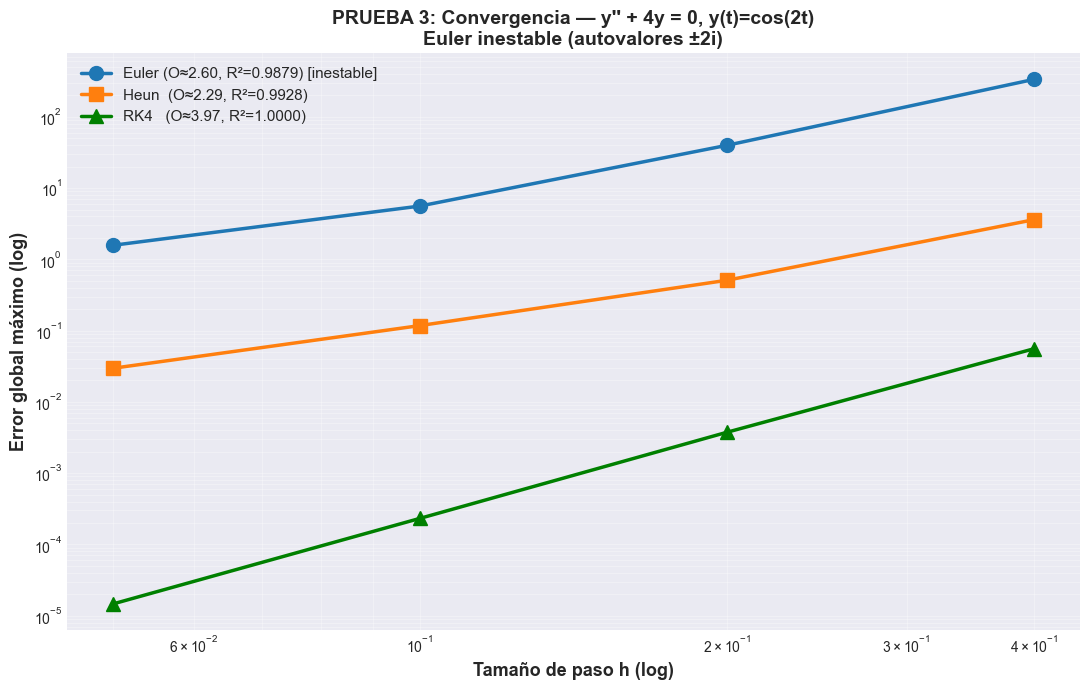


Órdenes observados:  Euler=2.604 (inestable)  Heun=2.289  RK4=3.971


In [14]:
fig, ax = plt.subplots(figsize=(11, 7))
e_e = df_p3['Euler'].values; e_h = df_p3['Heun'].values; e_r = df_p3['RK4'].values
o_e, r_e = calcular_orden_convergencia(pasos_h, e_e)
o_h, r_h = calcular_orden_convergencia(pasos_h, e_h)
o_r, r_r = calcular_orden_convergencia(pasos_h, e_r)
resumen_ordenes['P3'] = (o_e, o_h, o_r)

ax.loglog(pasos_h, e_e, 'o-', label=f'Euler (O\u2248{o_e:.2f}, R\u00b2={r_e:.4f}) [inestable]', linewidth=2.5, markersize=10)
ax.loglog(pasos_h, e_h, 's-', label=f'Heun  (O\u2248{o_h:.2f}, R\u00b2={r_h:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h, e_r, '^-', label=f'RK4   (O\u2248{o_r:.2f}, R\u00b2={r_r:.4f})', linewidth=2.5, markersize=10, color='green')
ax.set_xlabel('Tamaño de paso h (log)', fontsize=13, fontweight='bold')
ax.set_ylabel('Error global máximo (log)', fontsize=13, fontweight='bold')
ax.set_title("PRUEBA 3: Convergencia \u2014 y'' + 4y = 0, y(t)=cos(2t)\nEuler inestable (autovalores \u00b12i)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p3_convergencia.png', dpi=300); plt.show()

print(f"\nÓrdenes observados:  Euler={o_e:.3f} (inestable)  Heun={o_h:.3f}  RK4={o_r:.3f}")

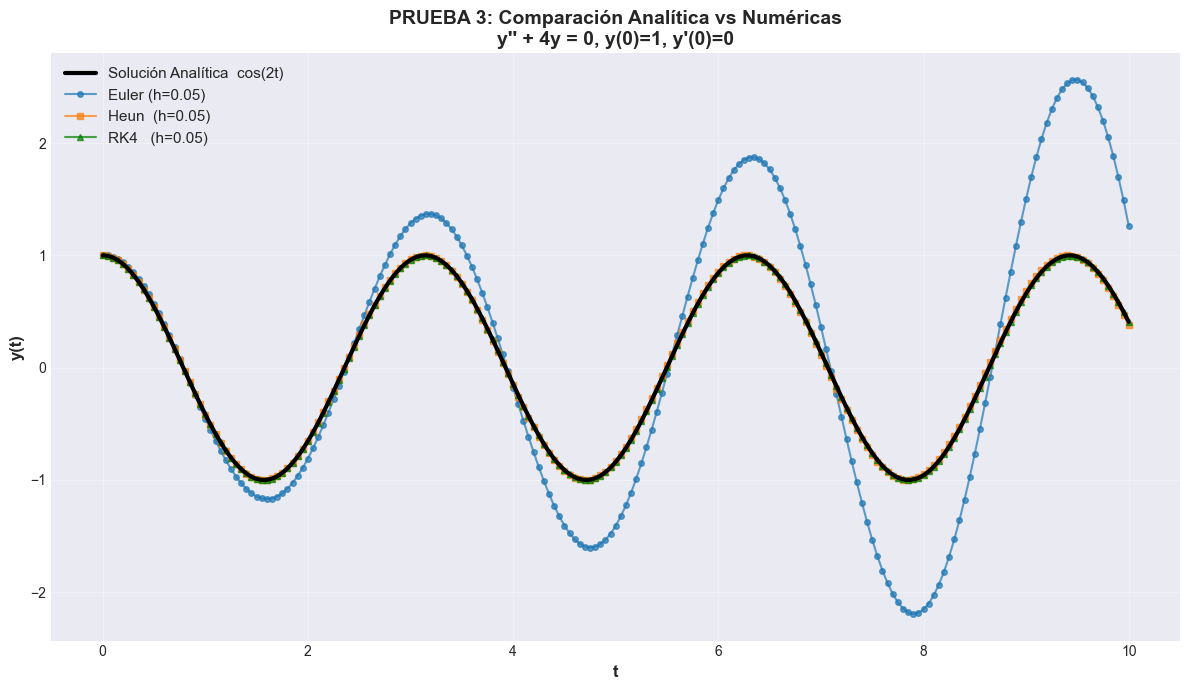

In [15]:
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h_comp); t_r, y_r = s.rk4()
t_ex = np.linspace(0, 10, 500); y_ex = EcuacionesPrueba.sol_exacta_edo2_1(t_ex)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(t_ex, y_ex, 'k-', linewidth=3, label='Solución Analítica  cos(2t)', zorder=5)
ax.plot(t_e, y_e[:, 0], 'o-', label=f'Euler (h={h_comp})', alpha=0.7, markersize=4)
ax.plot(t_h, y_h[:, 0], 's-', label=f'Heun  (h={h_comp})', alpha=0.7, markersize=4)
ax.plot(t_r, y_r[:, 0], '^-', label=f'RK4   (h={h_comp})', alpha=0.7, markersize=4, color='green')
ax.set_xlabel('t', fontsize=12, fontweight='bold'); ax.set_ylabel('y(t)', fontsize=12, fontweight='bold')
ax.set_title("PRUEBA 3: Comparación Analítica vs Numéricas\ny'' + 4y = 0, y(0)=1, y'(0)=0", fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p3_comparacion.png', dpi=300); plt.show()

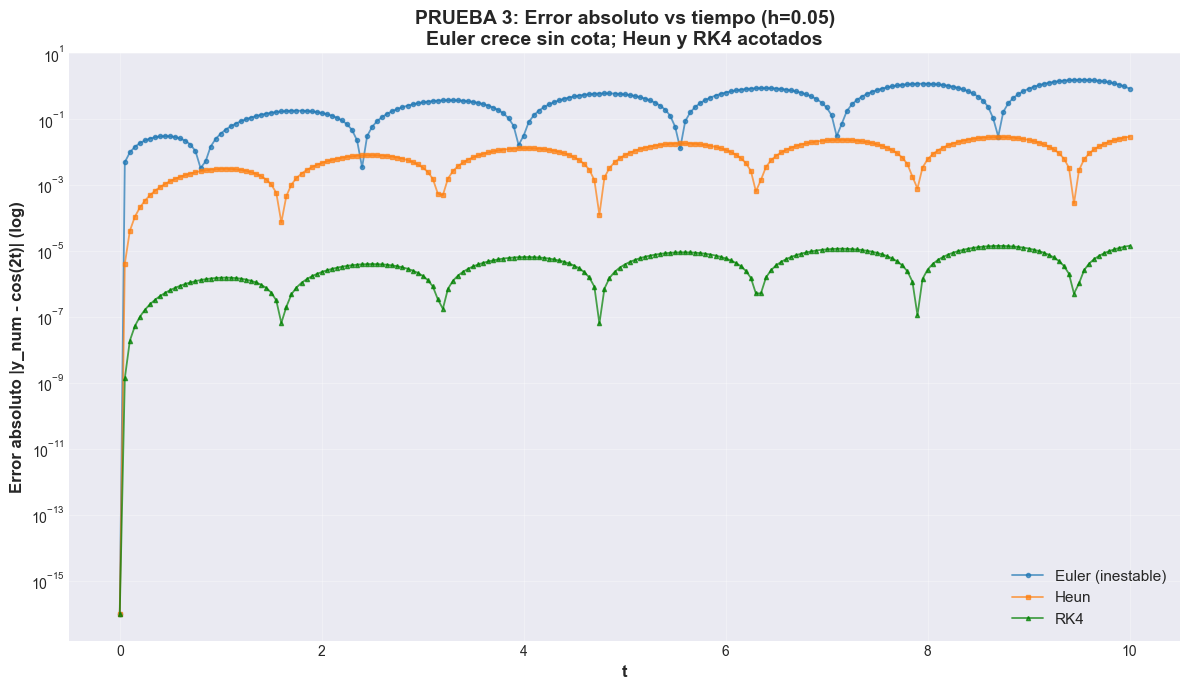

In [16]:
# Error absoluto vs tiempo (semilog) - P3  (componente y = cos(2t))
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.edo2_1, 0, 10, np.array([1.0, 0.0]), h_comp); t_r, y_r = s.rk4()

err_e = np.maximum(np.abs(y_e[:, 0] - EcuacionesPrueba.sol_exacta_edo2_1(t_e)), 1e-16)
err_h = np.maximum(np.abs(y_h[:, 0] - EcuacionesPrueba.sol_exacta_edo2_1(t_h)), 1e-16)
err_r = np.maximum(np.abs(y_r[:, 0] - EcuacionesPrueba.sol_exacta_edo2_1(t_r)), 1e-16)

fig, ax = plt.subplots(figsize=(12, 7))
ax.semilogy(t_e, err_e, 'o-', label='Euler (inestable)', alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_h, err_h, 's-', label='Heun',  alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_r, err_r, '^-', label='RK4',   alpha=0.7, linewidth=1.3, markersize=3, color='green')
ax.set_xlabel('t', fontsize=12, fontweight='bold')
ax.set_ylabel('Error absoluto |y_num - cos(2t)| (log)', fontsize=12, fontweight='bold')
ax.set_title("PRUEBA 3: Error absoluto vs tiempo (h=0.05)\nEuler crece sin cota; Heun y RK4 acotados", fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p3_error_tiempo.png', dpi=300); plt.show()

In [17]:
print("="*70)
print("PRUEBA 4: x' = 3x - 5y, y' = 8x - 12y,  x(0)=1, y(0)=0")
print("Solución analítica exacta: autovalores (-9 +- sqrt(65))/2")
print("="*70)

pasos_h_p4 = np.array([0.10, 0.05, 0.025, 0.0125])
resultados_p4 = []
for h in pasos_h_p4:
    s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h)
    t_e, y_e = s.euler_explicito(); ev_e = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h)
    t_h, y_h = s.heun_rk2();        ev_h = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h)
    t_r, y_r = s.rk4();             ev_r = s.evals_f

    sol_e = np.array([EcuacionesPrueba.sol_exacta_sistema1_lineal(ti) for ti in t_e])
    sol_h = np.array([EcuacionesPrueba.sol_exacta_sistema1_lineal(ti) for ti in t_h])
    sol_r = np.array([EcuacionesPrueba.sol_exacta_sistema1_lineal(ti) for ti in t_r])

    err_e = np.max(np.abs(y_e - sol_e))
    err_h = np.max(np.abs(y_h - sol_h))
    err_r = np.max(np.abs(y_r - sol_r))

    resultados_p4.append({'h': h, 'Euler': err_e, 'Heun': err_h, 'RK4': err_r,
        'Evals_Euler': ev_e, 'Evals_Heun': ev_h, 'Evals_RK4': ev_r})

df_p4 = pd.DataFrame(resultados_p4)
print("\nErrores globales máximos (vs solución analítica exacta):")
print(df_p4[['h','Euler','Heun','RK4']].to_string(index=False))
df_p4.to_csv('datos finales/prueba4_sistema_lineal1.csv', index=False)
print("\n\u2713 Resultados exportados a CSV")

PRUEBA 4: x' = 3x - 5y, y' = 8x - 12y,  x(0)=1, y(0)=0
Solución analítica exacta: autovalores (-9 +- sqrt(65))/2

Errores globales máximos (vs solución analítica exacta):
     h    Euler     Heun          RK4
0.1000 0.275970 0.084030 3.263816e-03
0.0500 0.095970 0.015243 1.422460e-04
0.0250 0.042416 0.003254 7.506056e-06
0.0125 0.020238 0.000749 4.296399e-07

✓ Resultados exportados a CSV


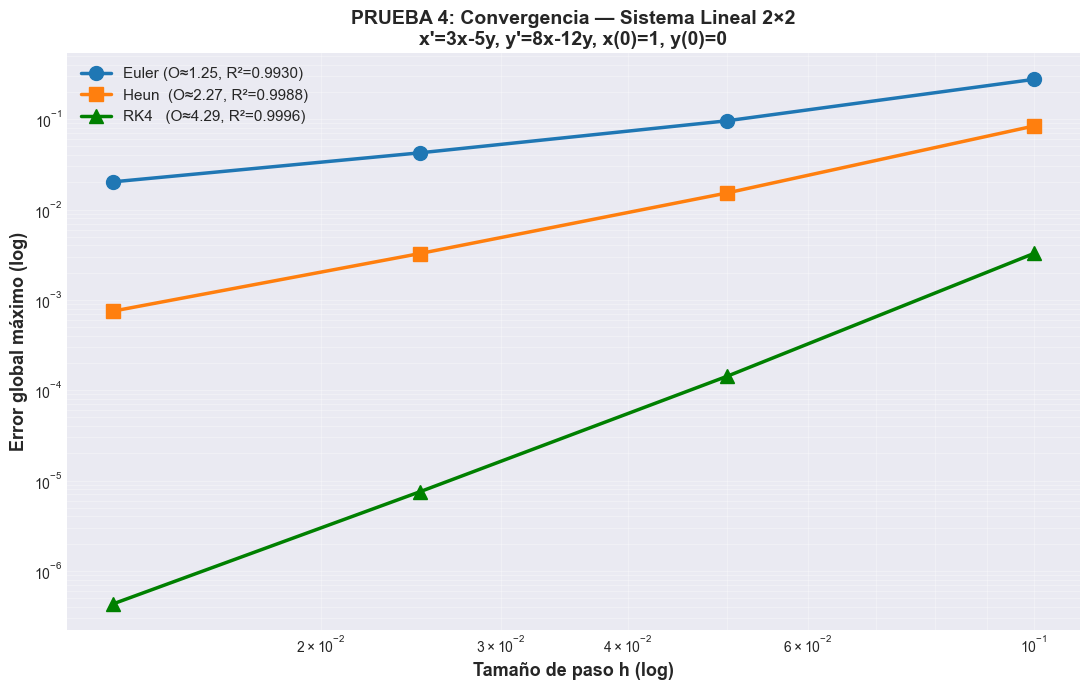


Órdenes observados:  Euler=1.249  Heun=2.265  RK4=4.292


In [18]:
fig, ax = plt.subplots(figsize=(11, 7))
e_e = df_p4['Euler'].values; e_h = df_p4['Heun'].values; e_r = df_p4['RK4'].values
o_e, r_e = calcular_orden_convergencia(pasos_h_p4, e_e)
o_h, r_h = calcular_orden_convergencia(pasos_h_p4, e_h)
o_r, r_r = calcular_orden_convergencia(pasos_h_p4, e_r)
resumen_ordenes['P4'] = (o_e, o_h, o_r)

ax.loglog(pasos_h_p4, e_e, 'o-', label=f'Euler (O\u2248{o_e:.2f}, R\u00b2={r_e:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h_p4, e_h, 's-', label=f'Heun  (O\u2248{o_h:.2f}, R\u00b2={r_h:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h_p4, e_r, '^-', label=f'RK4   (O\u2248{o_r:.2f}, R\u00b2={r_r:.4f})', linewidth=2.5, markersize=10, color='green')
ax.set_xlabel('Tamaño de paso h (log)', fontsize=13, fontweight='bold')
ax.set_ylabel('Error global máximo (log)', fontsize=13, fontweight='bold')
ax.set_title("PRUEBA 4: Convergencia \u2014 Sistema Lineal 2\u00d72\nx'=3x-5y, y'=8x-12y, x(0)=1, y(0)=0", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p4_convergencia.png', dpi=300); plt.show()

print(f"\nÓrdenes observados:  Euler={o_e:.3f}  Heun={o_h:.3f}  RK4={o_r:.3f}")

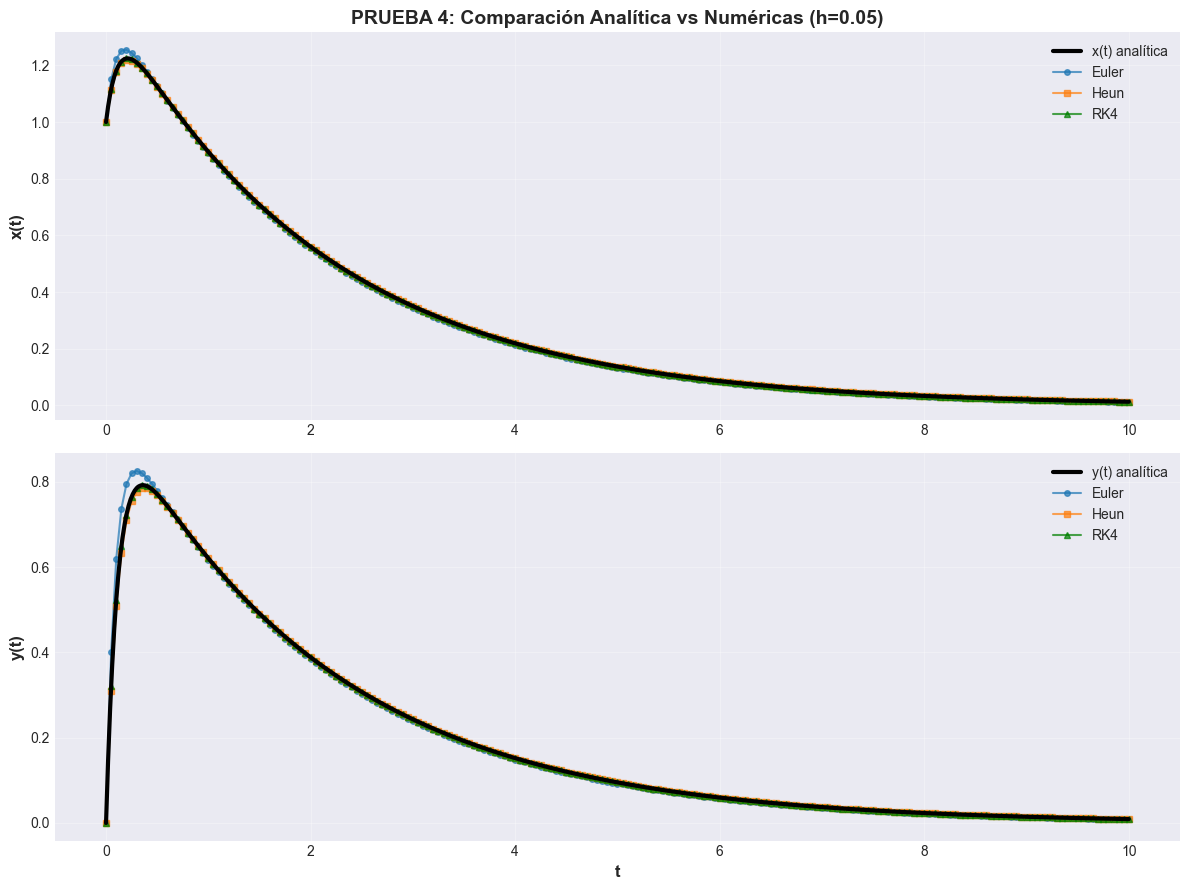

In [19]:
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h_comp); t_r, y_r = s.rk4()
t_ex = np.linspace(0, 10, 500)
sol_ex = np.array([EcuacionesPrueba.sol_exacta_sistema1_lineal(ti) for ti in t_ex])

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
axes[0].plot(t_ex, sol_ex[:, 0], 'k-', linewidth=3, label='x(t) analítica', zorder=5)
axes[0].plot(t_e, y_e[:, 0], 'o-', label='Euler', alpha=0.7, markersize=4)
axes[0].plot(t_h, y_h[:, 0], 's-', label='Heun', alpha=0.7, markersize=4)
axes[0].plot(t_r, y_r[:, 0], '^-', label='RK4', alpha=0.7, markersize=4, color='green')
axes[0].set_ylabel('x(t)', fontsize=12, fontweight='bold')
axes[0].set_title("PRUEBA 4: Comparación Analítica vs Numéricas (h=0.05)", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_ex, sol_ex[:, 1], 'k-', linewidth=3, label='y(t) analítica', zorder=5)
axes[1].plot(t_e, y_e[:, 1], 'o-', label='Euler', alpha=0.7, markersize=4)
axes[1].plot(t_h, y_h[:, 1], 's-', label='Heun', alpha=0.7, markersize=4)
axes[1].plot(t_r, y_r[:, 1], '^-', label='RK4', alpha=0.7, markersize=4, color='green')
axes[1].set_xlabel('t', fontsize=12, fontweight='bold'); axes[1].set_ylabel('y(t)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p4_comparacion.png', dpi=300); plt.show()

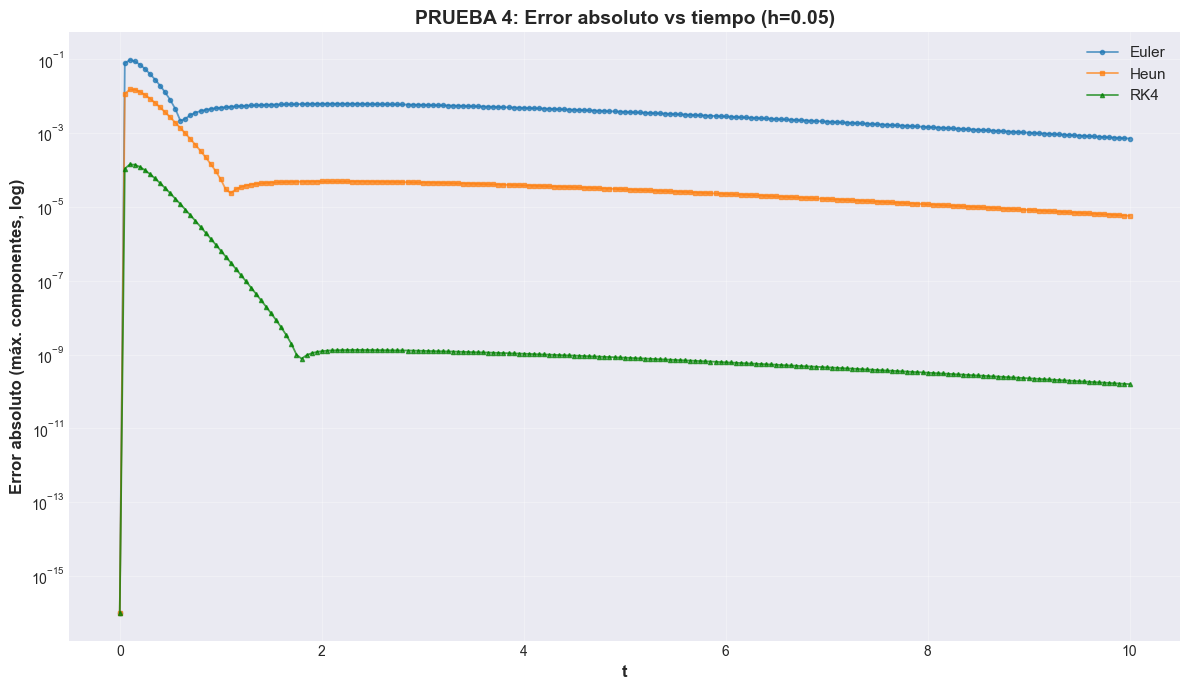

In [20]:
# Error absoluto vs tiempo (semilog) - P4  (máximo sobre componentes)
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 0.0]), h_comp); t_r, y_r = s.rk4()

ex_e = np.array([EcuacionesPrueba.sol_exacta_sistema1_lineal(ti) for ti in t_e])
ex_h = np.array([EcuacionesPrueba.sol_exacta_sistema1_lineal(ti) for ti in t_h])
ex_r = np.array([EcuacionesPrueba.sol_exacta_sistema1_lineal(ti) for ti in t_r])

err_e = np.maximum(np.max(np.abs(y_e - ex_e), axis=1), 1e-16)
err_h = np.maximum(np.max(np.abs(y_h - ex_h), axis=1), 1e-16)
err_r = np.maximum(np.max(np.abs(y_r - ex_r), axis=1), 1e-16)

fig, ax = plt.subplots(figsize=(12, 7))
ax.semilogy(t_e, err_e, 'o-', label='Euler', alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_h, err_h, 's-', label='Heun',  alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_r, err_r, '^-', label='RK4',   alpha=0.7, linewidth=1.3, markersize=3, color='green')
ax.set_xlabel('t', fontsize=12, fontweight='bold')
ax.set_ylabel('Error absoluto (máx. componentes, log)', fontsize=12, fontweight='bold')
ax.set_title("PRUEBA 4: Error absoluto vs tiempo (h=0.05)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p4_error_tiempo.png', dpi=300); plt.show()

In [21]:
print("="*70)
print("PRUEBA 5: dx/dt = -x + y, dy/dt = -2y,  x(0)=1, y(0)=1")
print("Solución exacta: x(t) = 2e^(-t) - e^(-2t),  y(t) = e^(-2t)")
print("="*70)

resultados_p5 = []
for h in pasos_h:
    s = MetodosNumericos(EcuacionesPrueba.sistema2_lineal, 0, 10, np.array([1.0, 1.0]), h)
    t_e, y_e = s.euler_explicito(); ev_e = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.sistema2_lineal, 0, 10, np.array([1.0, 1.0]), h)
    t_h, y_h = s.heun_rk2();        ev_h = s.evals_f
    s = MetodosNumericos(EcuacionesPrueba.sistema2_lineal, 0, 10, np.array([1.0, 1.0]), h)
    t_r, y_r = s.rk4();             ev_r = s.evals_f

    ex_e = np.column_stack([2*np.exp(-t_e) - np.exp(-2*t_e), np.exp(-2*t_e)])
    ex_h = np.column_stack([2*np.exp(-t_h) - np.exp(-2*t_h), np.exp(-2*t_h)])
    ex_r = np.column_stack([2*np.exp(-t_r) - np.exp(-2*t_r), np.exp(-2*t_r)])

    err_e = np.max(np.abs(y_e - ex_e))
    err_h = np.max(np.abs(y_h - ex_h))
    err_r = np.max(np.abs(y_r - ex_r))

    resultados_p5.append({'h': h, 'Euler': err_e, 'Heun': err_h, 'RK4': err_r,
        'Evals_Euler': ev_e, 'Evals_Heun': ev_h, 'Evals_RK4': ev_r})

df_p5 = pd.DataFrame(resultados_p5)
print("\nErrores globales máximos (vs solución exacta):")
print(df_p5[['h','Euler','Heun','RK4']].to_string(index=False))
df_p5.to_csv('datos finales/prueba5_sistema_lineal2.csv', index=False)
print("\n\u2713 Resultados exportados a CSV")

PRUEBA 5: dx/dt = -x + y, dy/dt = -2y,  x(0)=1, y(0)=1
Solución exacta: x(t) = 2e^(-t) - e^(-2t),  y(t) = e^(-2t)

Errores globales máximos (vs solución exacta):
   h    Euler     Heun          RK4
0.40 0.249329 0.070671 2.404369e-03
0.20 0.089329 0.013238 1.077898e-04
0.10 0.040199 0.002860 5.796954e-06
0.05 0.019201 0.000662 3.332411e-07

✓ Resultados exportados a CSV


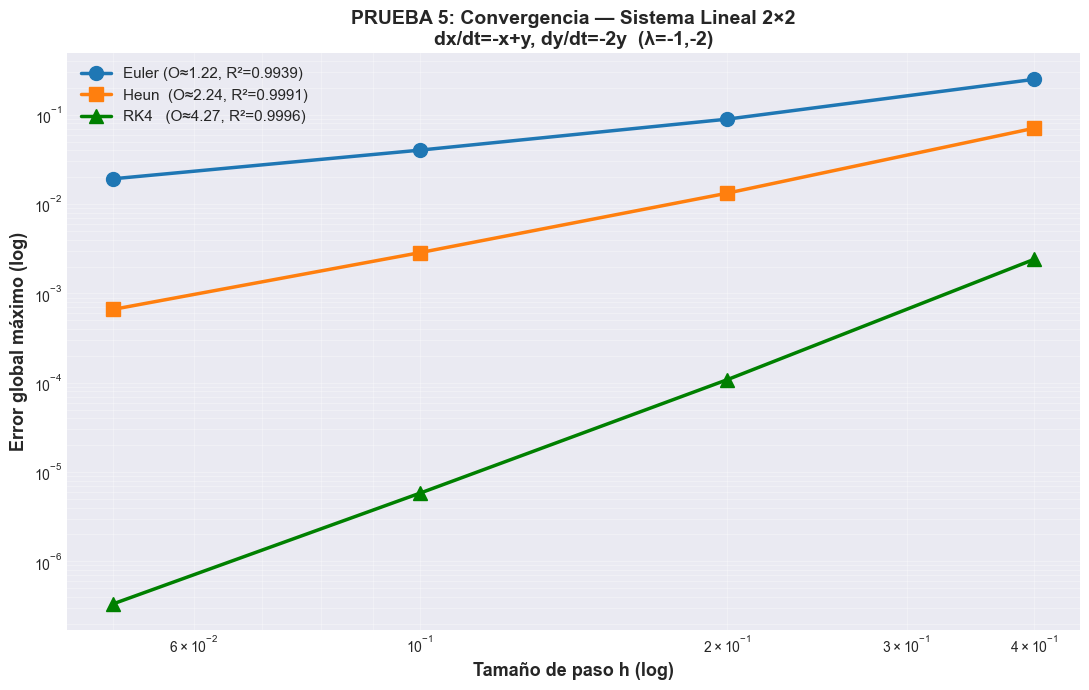


Órdenes observados:  Euler=1.225  Heun=2.243  RK4=4.267


In [22]:
fig, ax = plt.subplots(figsize=(11, 7))
e_e = df_p5['Euler'].values; e_h = df_p5['Heun'].values; e_r = df_p5['RK4'].values
o_e, r_e = calcular_orden_convergencia(pasos_h, e_e)
o_h, r_h = calcular_orden_convergencia(pasos_h, e_h)
o_r, r_r = calcular_orden_convergencia(pasos_h, e_r)
resumen_ordenes['P5'] = (o_e, o_h, o_r)

ax.loglog(pasos_h, e_e, 'o-', label=f'Euler (O\u2248{o_e:.2f}, R\u00b2={r_e:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h, e_h, 's-', label=f'Heun  (O\u2248{o_h:.2f}, R\u00b2={r_h:.4f})', linewidth=2.5, markersize=10)
ax.loglog(pasos_h, e_r, '^-', label=f'RK4   (O\u2248{o_r:.2f}, R\u00b2={r_r:.4f})', linewidth=2.5, markersize=10, color='green')
ax.set_xlabel('Tamaño de paso h (log)', fontsize=13, fontweight='bold')
ax.set_ylabel('Error global máximo (log)', fontsize=13, fontweight='bold')
ax.set_title("PRUEBA 5: Convergencia \u2014 Sistema Lineal 2\u00d72\ndx/dt=-x+y, dy/dt=-2y  (\u03bb=-1,-2)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p5_convergencia.png', dpi=300); plt.show()

print(f"\nÓrdenes observados:  Euler={o_e:.3f}  Heun={o_h:.3f}  RK4={o_r:.3f}")

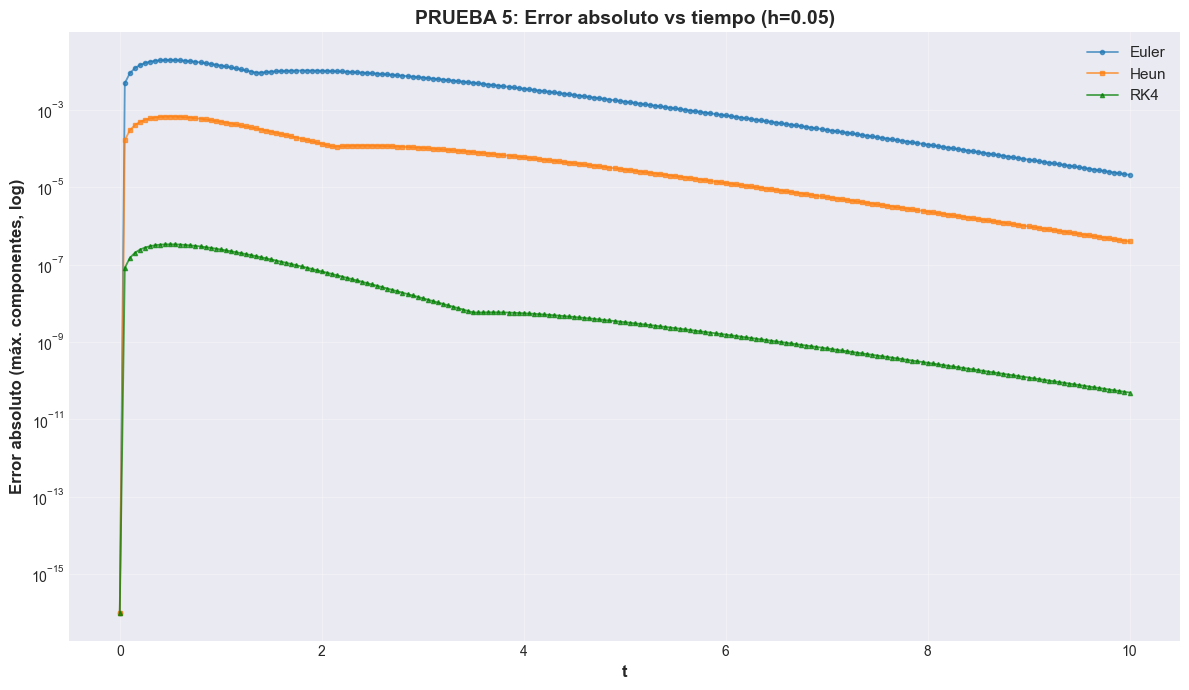

In [23]:
# Error absoluto vs tiempo (semilog) - P5  (máximo sobre componentes)
h_comp = 0.05
s = MetodosNumericos(EcuacionesPrueba.sistema2_lineal, 0, 10, np.array([1.0, 1.0]), h_comp); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.sistema2_lineal, 0, 10, np.array([1.0, 1.0]), h_comp); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.sistema2_lineal, 0, 10, np.array([1.0, 1.0]), h_comp); t_r, y_r = s.rk4()

ex_e = np.column_stack([2*np.exp(-t_e) - np.exp(-2*t_e), np.exp(-2*t_e)])
ex_h = np.column_stack([2*np.exp(-t_h) - np.exp(-2*t_h), np.exp(-2*t_h)])
ex_r = np.column_stack([2*np.exp(-t_r) - np.exp(-2*t_r), np.exp(-2*t_r)])

err_e = np.maximum(np.max(np.abs(y_e - ex_e), axis=1), 1e-16)
err_h = np.maximum(np.max(np.abs(y_h - ex_h), axis=1), 1e-16)
err_r = np.maximum(np.max(np.abs(y_r - ex_r), axis=1), 1e-16)

fig, ax = plt.subplots(figsize=(12, 7))
ax.semilogy(t_e, err_e, 'o-', label='Euler', alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_h, err_h, 's-', label='Heun',  alpha=0.7, linewidth=1.3, markersize=3)
ax.semilogy(t_r, err_r, '^-', label='RK4',   alpha=0.7, linewidth=1.3, markersize=3, color='green')
ax.set_xlabel('t', fontsize=12, fontweight='bold')
ax.set_ylabel('Error absoluto (máx. componentes, log)', fontsize=12, fontweight='bold')
ax.set_title("PRUEBA 5: Error absoluto vs tiempo (h=0.05)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/p5_error_tiempo.png', dpi=300); plt.show()

In [24]:
print("="*70)
print("PRUEBA 6: Lotka-Volterra (1)  dx/dt = x - xy, dy/dt = xy - y")
print("Condición inicial: x(0) = 2, y(0) = 1")
print("="*70)

h = 0.05
s = MetodosNumericos(EcuacionesPrueba.lotka_volterra1, 0, 10, np.array([2.0, 1.0]), h); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.lotka_volterra1, 0, 10, np.array([2.0, 1.0]), h); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.lotka_volterra1, 0, 10, np.array([2.0, 1.0]), h); t_r, y_r = s.rk4()
print(f"\nSimulación completada con h = {h}  ({len(t_r)} puntos)")

PRUEBA 6: Lotka-Volterra (1)  dx/dt = x - xy, dy/dt = xy - y
Condición inicial: x(0) = 2, y(0) = 1

Simulación completada con h = 0.05  (201 puntos)


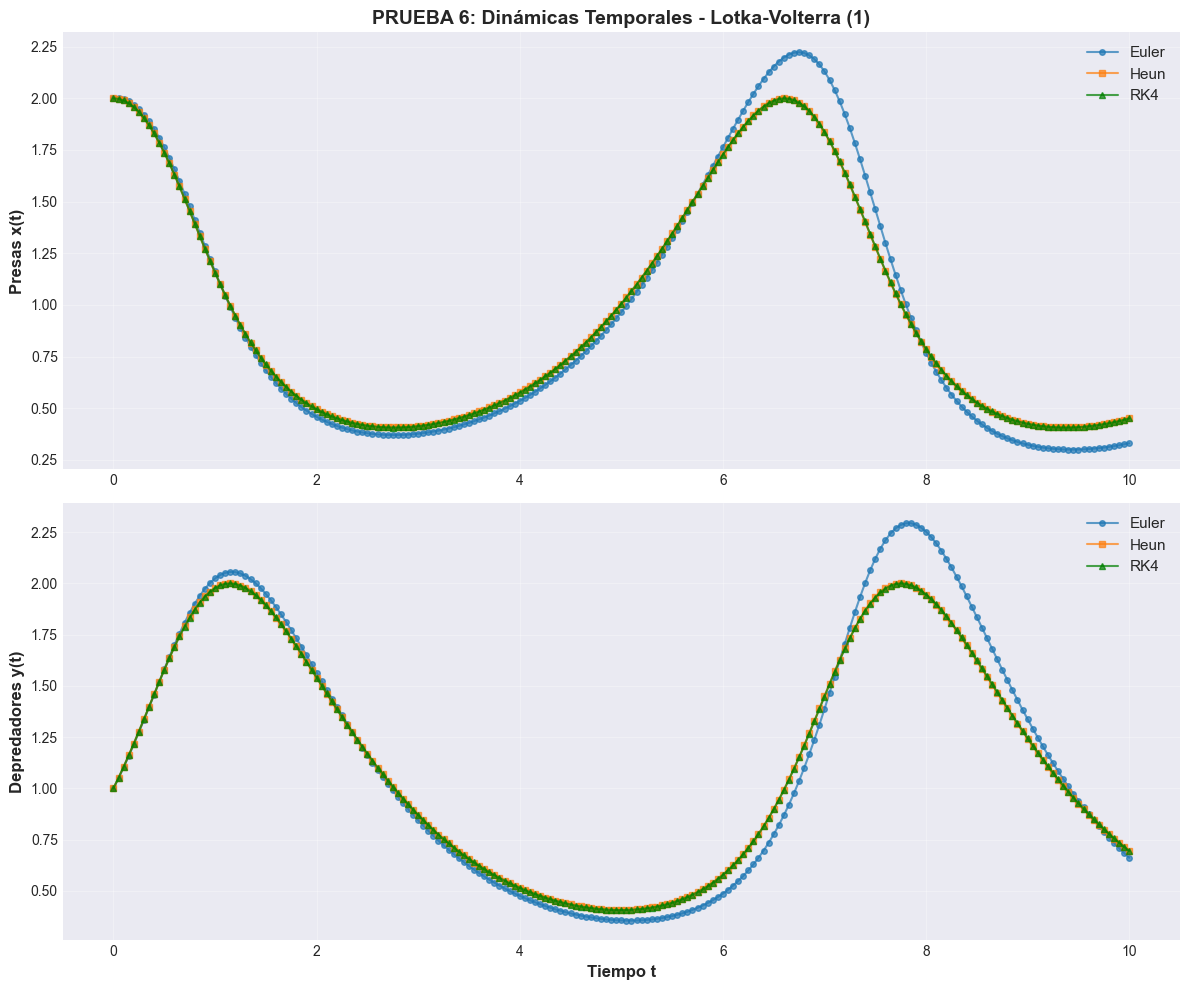

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].plot(t_e, y_e[:, 0], 'o-', label='Euler', alpha=0.7, linewidth=1.5, markersize=4)
axes[0].plot(t_h, y_h[:, 0], 's-', label='Heun', alpha=0.7, linewidth=1.5, markersize=4)
axes[0].plot(t_r, y_r[:, 0], '^-', label='RK4', alpha=0.7, linewidth=1.5, markersize=4, color='green')
axes[0].set_ylabel('Presas x(t)', fontsize=12, fontweight='bold')
axes[0].set_title('PRUEBA 6: Dinámicas Temporales - Lotka-Volterra (1)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)
axes[1].plot(t_e, y_e[:, 1], 'o-', label='Euler', alpha=0.7, linewidth=1.5, markersize=4)
axes[1].plot(t_h, y_h[:, 1], 's-', label='Heun', alpha=0.7, linewidth=1.5, markersize=4)
axes[1].plot(t_r, y_r[:, 1], '^-', label='RK4', alpha=0.7, linewidth=1.5, markersize=4, color='green')
axes[1].set_xlabel('Tiempo t', fontsize=12, fontweight='bold'); axes[1].set_ylabel('Depredadores y(t)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/prueba6_dinamicas.png', dpi=300); plt.show()

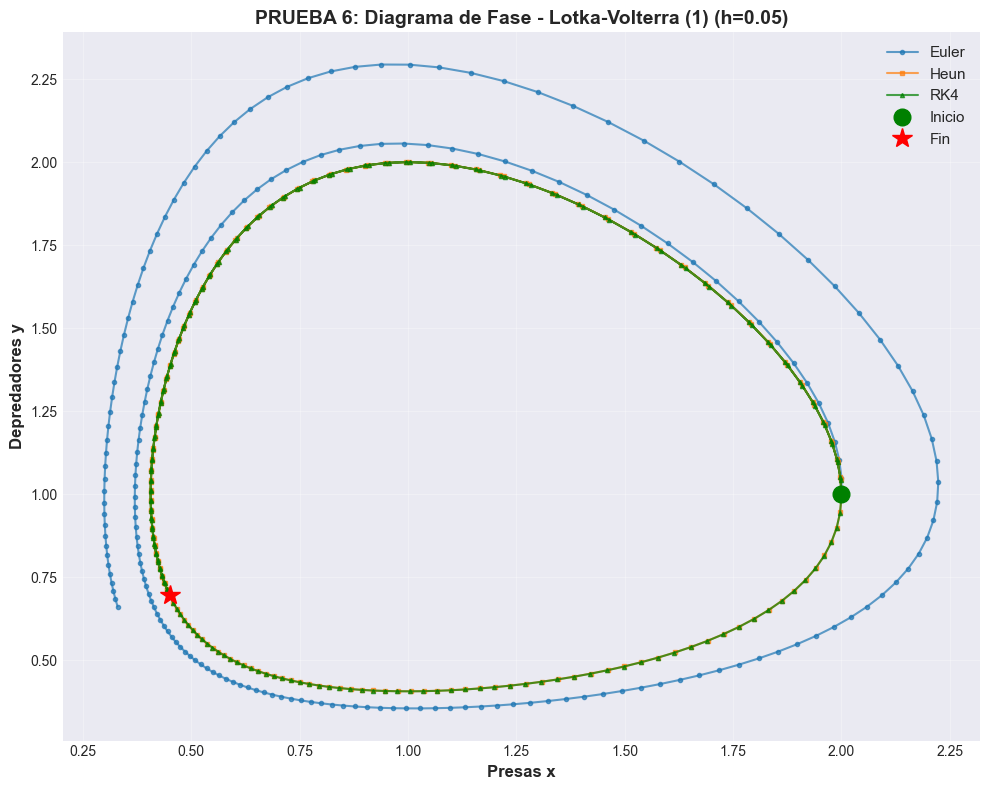

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(y_e[:, 0], y_e[:, 1], 'o-', label='Euler', alpha=0.7, linewidth=1.5, markersize=3)
ax.plot(y_h[:, 0], y_h[:, 1], 's-', label='Heun', alpha=0.7, linewidth=1.5, markersize=3)
ax.plot(y_r[:, 0], y_r[:, 1], '^-', label='RK4', alpha=0.7, linewidth=1.5, markersize=3, color='green')
ax.plot(y_r[0, 0], y_r[0, 1], 'go', markersize=12, label='Inicio', zorder=5)
ax.plot(y_r[-1, 0], y_r[-1, 1], 'r*', markersize=15, label='Fin', zorder=5)
ax.set_xlabel('Presas x', fontsize=12, fontweight='bold'); ax.set_ylabel('Depredadores y', fontsize=12, fontweight='bold')
ax.set_title('PRUEBA 6: Diagrama de Fase - Lotka-Volterra (1) (h=0.05)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/prueba6_fase.png', dpi=300); plt.show()

In [27]:
print("="*70)
print("PRUEBA 7: Lotka-Volterra (2)  dx/dt = 1.1x - 0.4xy, dy/dt = 0.1xy - 0.4y")
print("Condición inicial: x(0) = 10, y(0) = 5")
print("="*70)

h = 0.05
s = MetodosNumericos(EcuacionesPrueba.lotka_volterra2, 0, 10, np.array([10.0, 5.0]), h); t_e, y_e = s.euler_explicito()
s = MetodosNumericos(EcuacionesPrueba.lotka_volterra2, 0, 10, np.array([10.0, 5.0]), h); t_h, y_h = s.heun_rk2()
s = MetodosNumericos(EcuacionesPrueba.lotka_volterra2, 0, 10, np.array([10.0, 5.0]), h); t_r, y_r = s.rk4()
print(f"\nSimulación completada con h = {h}  ({len(t_r)} puntos)")

PRUEBA 7: Lotka-Volterra (2)  dx/dt = 1.1x - 0.4xy, dy/dt = 0.1xy - 0.4y
Condición inicial: x(0) = 10, y(0) = 5

Simulación completada con h = 0.05  (201 puntos)


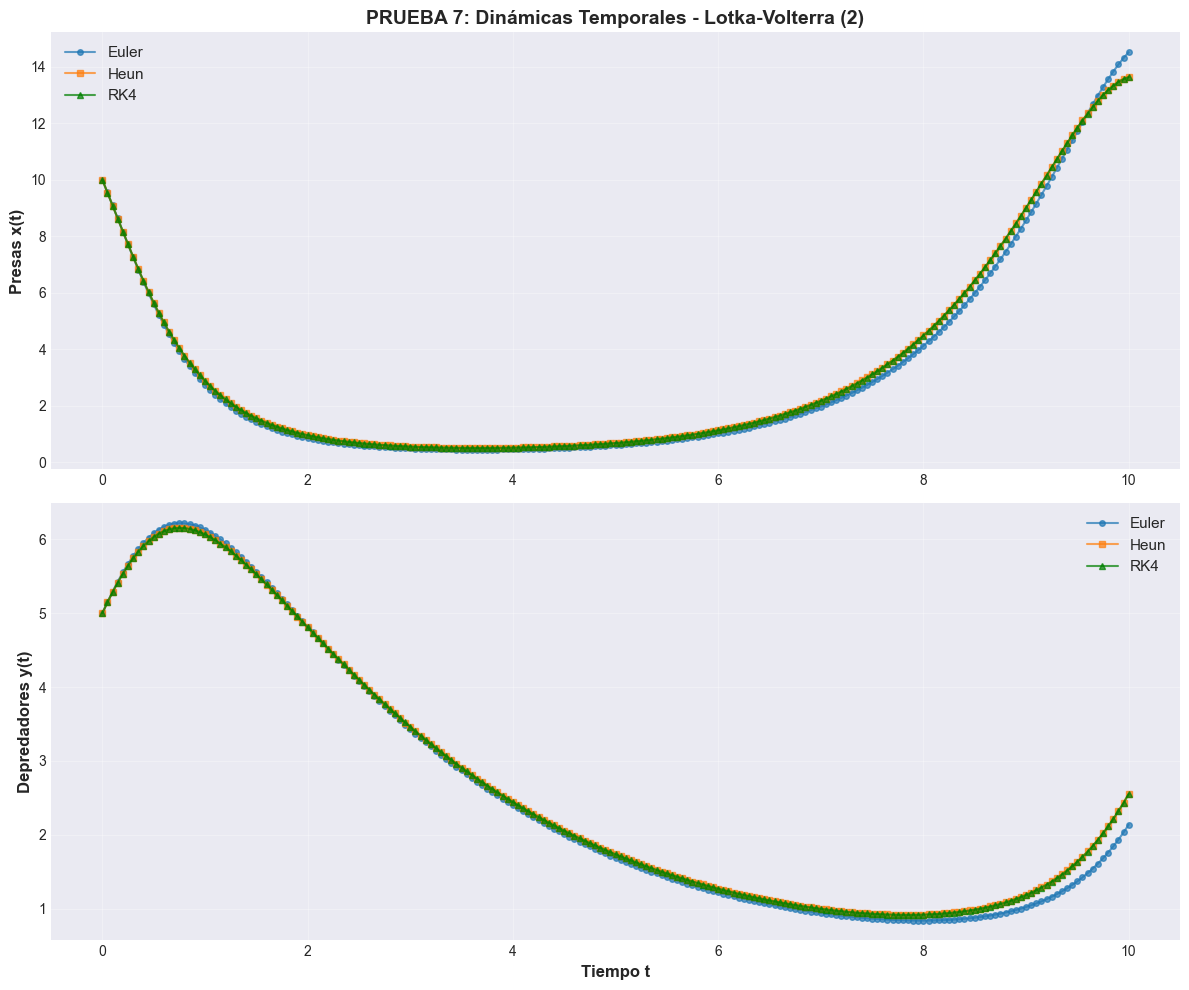

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].plot(t_e, y_e[:, 0], 'o-', label='Euler', alpha=0.7, linewidth=1.5, markersize=4)
axes[0].plot(t_h, y_h[:, 0], 's-', label='Heun', alpha=0.7, linewidth=1.5, markersize=4)
axes[0].plot(t_r, y_r[:, 0], '^-', label='RK4', alpha=0.7, linewidth=1.5, markersize=4, color='green')
axes[0].set_ylabel('Presas x(t)', fontsize=12, fontweight='bold')
axes[0].set_title('PRUEBA 7: Dinámicas Temporales - Lotka-Volterra (2)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)
axes[1].plot(t_e, y_e[:, 1], 'o-', label='Euler', alpha=0.7, linewidth=1.5, markersize=4)
axes[1].plot(t_h, y_h[:, 1], 's-', label='Heun', alpha=0.7, linewidth=1.5, markersize=4)
axes[1].plot(t_r, y_r[:, 1], '^-', label='RK4', alpha=0.7, linewidth=1.5, markersize=4, color='green')
axes[1].set_xlabel('Tiempo t', fontsize=12, fontweight='bold'); axes[1].set_ylabel('Depredadores y(t)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/prueba7_dinamicas.png', dpi=300); plt.show()

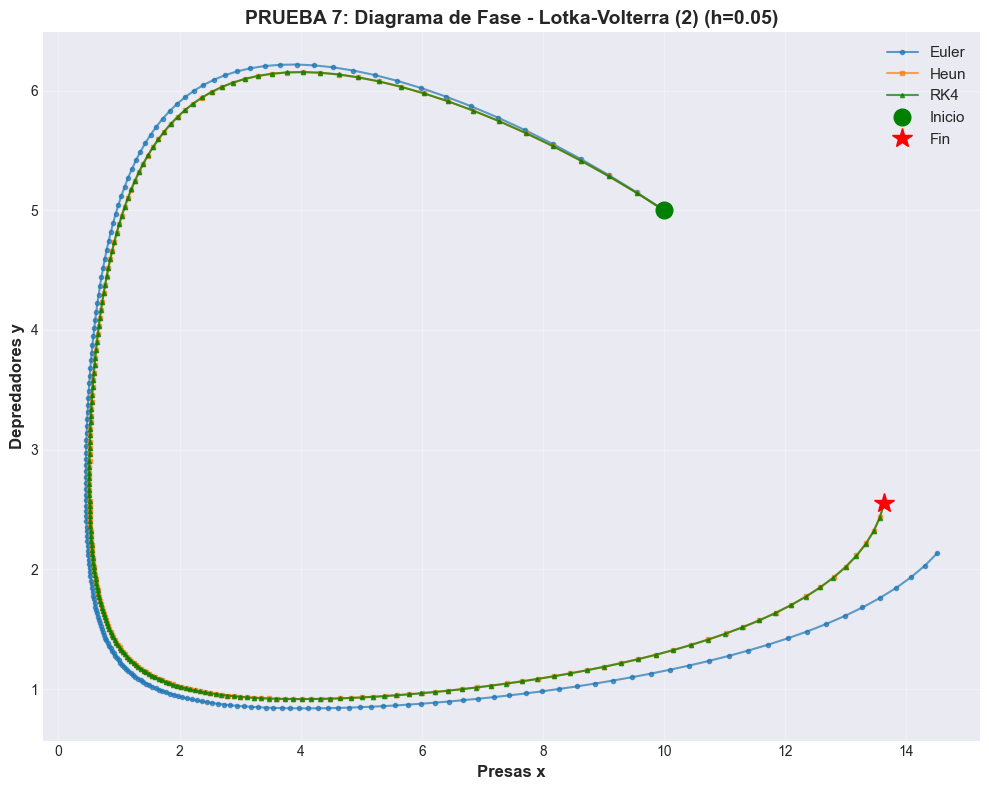

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(y_e[:, 0], y_e[:, 1], 'o-', label='Euler', alpha=0.7, linewidth=1.5, markersize=3)
ax.plot(y_h[:, 0], y_h[:, 1], 's-', label='Heun', alpha=0.7, linewidth=1.5, markersize=3)
ax.plot(y_r[:, 0], y_r[:, 1], '^-', label='RK4', alpha=0.7, linewidth=1.5, markersize=3, color='green')
ax.plot(y_r[0, 0], y_r[0, 1], 'go', markersize=12, label='Inicio', zorder=5)
ax.plot(y_r[-1, 0], y_r[-1, 1], 'r*', markersize=15, label='Fin', zorder=5)
ax.set_xlabel('Presas x', fontsize=12, fontweight='bold'); ax.set_ylabel('Depredadores y', fontsize=12, fontweight='bold')
ax.set_title('PRUEBA 7: Diagrama de Fase - Lotka-Volterra (2) (h=0.05)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('datos finales/prueba7_fase.png', dpi=300); plt.show()

In [30]:
print("="*70)
print("RESUMEN EJECUTIVO")
print("="*70)

print("\n1. ÓRDENES DE CONVERGENCIA OBSERVADOS (pendiente log-log):")
nombres = {'P1': "Prueba 1  y'=-2y+e^(-t)", 'P2': "Prueba 2  y'=y*cos(t)",
           'P3': "Prueba 3  y''+4y=0", 'P4': "Prueba 4  sistema 2x2",
           'P5': "Prueba 5  sistema 2x2"}
fila = pd.DataFrame(
    [{'Prueba': nombres[k], 'Euler': f"{v[0]:.2f}", 'Heun': f"{v[1]:.2f}", 'RK4': f"{v[2]:.2f}"}
     for k, v in resumen_ordenes.items()])
print(fila.to_string(index=False))
print("\n(Teórico esperado: Euler=1, Heun=2, RK4=4)")
print("Nota: en la Prueba 3 Euler es inestable, su pendiente no es representativa.")

print("\n2. COSTO POR PASO:")
print("   - Euler: 1 evaluación de f por paso")
print("   - Heun : 2 evaluaciones de f por paso")
print("   - RK4  : 4 evaluaciones de f por paso")
print("   -> RK4 ofrece la mejor relación precisión/costo para una tolerancia dada")

print("\n3. SISTEMAS NO LINEALES (Lotka-Volterra):")
print("   - Heun y RK4 conservan el ciclo presa-depredador")
print("   - Euler presenta deriva numérica acumulada (órbita no cierra)")

print("\n" + "="*70)
print("\u2713 ANÁLISIS COMPLETADO")
print("="*70)

RESUMEN EJECUTIVO

1. ÓRDENES DE CONVERGENCIA OBSERVADOS (pendiente log-log):
                 Prueba Euler Heun  RK4
Prueba 1  y'=-2y+e^(-t)  1.25 2.29 4.30
  Prueba 2  y'=y*cos(t)  0.90 2.10 4.20
     Prueba 3  y''+4y=0  2.60 2.29 3.97
  Prueba 4  sistema 2x2  1.25 2.27 4.29
  Prueba 5  sistema 2x2  1.22 2.24 4.27

(Teórico esperado: Euler=1, Heun=2, RK4=4)
Nota: en la Prueba 3 Euler es inestable, su pendiente no es representativa.

2. COSTO POR PASO:
   - Euler: 1 evaluación de f por paso
   - Heun : 2 evaluaciones de f por paso
   - RK4  : 4 evaluaciones de f por paso
   -> RK4 ofrece la mejor relación precisión/costo para una tolerancia dada

3. SISTEMAS NO LINEALES (Lotka-Volterra):
   - Heun y RK4 conservan el ciclo presa-depredador
   - Euler presenta deriva numérica acumulada (órbita no cierra)

✓ ANÁLISIS COMPLETADO
